# 🌌 HDBSCAN: A Step-by-Step Exercise

Welcome to this interactive exercise! In this notebook, we will explore **HDBSCAN** (Hierarchical Density-Based Spatial Clustering of Applications with Noise).

### Why HDBSCAN?
- **K-Means** forces every point into a cluster (even outliers) and assumes clusters are circular.
- **Standard Hierarchical Clustering** doesn't have a concept of "noise".
- **DBSCAN** handles noise and shapes well, but struggles if clusters have *varying densities*.

**HDBSCAN** solves all of this by combining density-based approaches with hierarchical trees. Let's walk through exactly how it works under the hood!

In [2]:
# Install hdbscan if you don't have it!
# !pip install hdbscan seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import hdbscan
from sklearn.datasets import make_blobs

# Set clean plotting styles
sns.set_context('poster')
sns.set_style('white')
sns.set_color_codes()
plot_kwds = {'alpha' : 0.5, 's' : 80, 'linewidths':0}

## Step 1: Create Complex Mock Data
To see HDBSCAN shine, we need a dataset that breaks simple algorithms. We will create:
1. A dense, tight cluster.
2. A sparse, spread-out cluster.
3. Lots of random background noise.

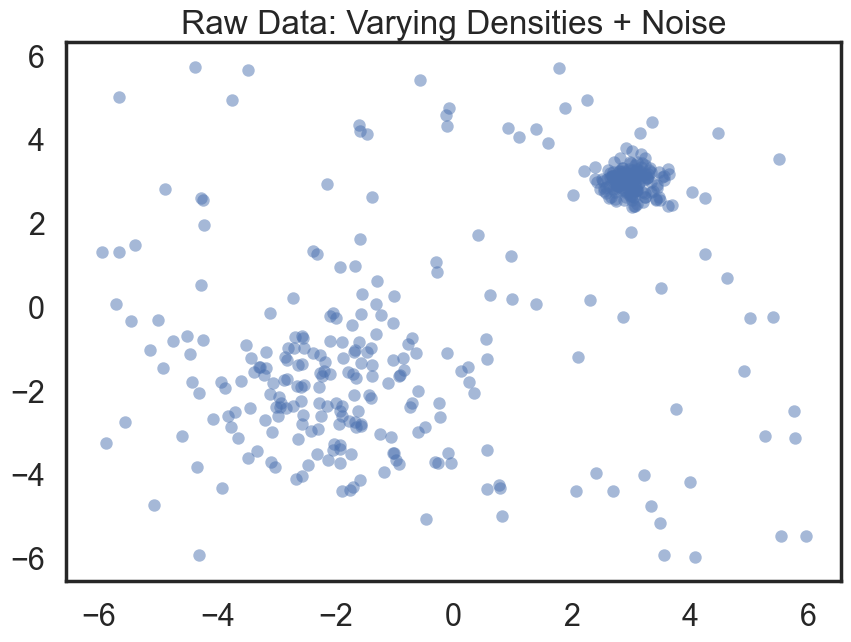

In [3]:
# 1. Create a tight dense cluster
c1, _ = make_blobs(n_samples=150, centers=[[3, 3]], cluster_std=0.3, random_state=42)

# 2. Create a loose sparse cluster
c2, _ = make_blobs(n_samples=150, centers=[[-2, -2]], cluster_std=1.2, random_state=42)

# 3. Create random background noise across the space
noise = np.random.uniform(low=-6, high=6, size=(100, 2))

# Combine them all into one dataset
data = np.vstack((c1, c2, noise))

plt.figure(figsize=(10, 7))
plt.scatter(data[:, 0], data[:, 1], color='b', **plot_kwds)
plt.title('Raw Data: Varying Densities + Noise')
plt.show()

## Step 2: Fit the HDBSCAN Model
Unlike K-Means, we do **not** tell HDBSCAN how many clusters to find. 
Instead, we give it a `min_cluster_size` (the smallest grouping we consider a valid "cluster").

*Note: We set `gen_min_span_tree=True` so the algorithm saves its intermediate math steps for us to visualize.*

In [4]:
# Initialize and fit the model
clusterer = hdbscan.HDBSCAN(min_cluster_size=15, gen_min_span_tree=True)
clusterer.fit(data)

print("Model successfully fitted!")

Model successfully fitted!


## Step 3: Transform Space (Mutual Reachability Distance)
Before HDBSCAN connects points, it pushes "noisy" points further away from everything else. 
It uses a metric called **Mutual Reachability Distance**. If a point is in a sparse, lonely area, the algorithm mathematically inflates its distance to other points. 

Once space is transformed, it builds a **Minimum Spanning Tree (MST)**—connecting all points with the shortest possible paths.

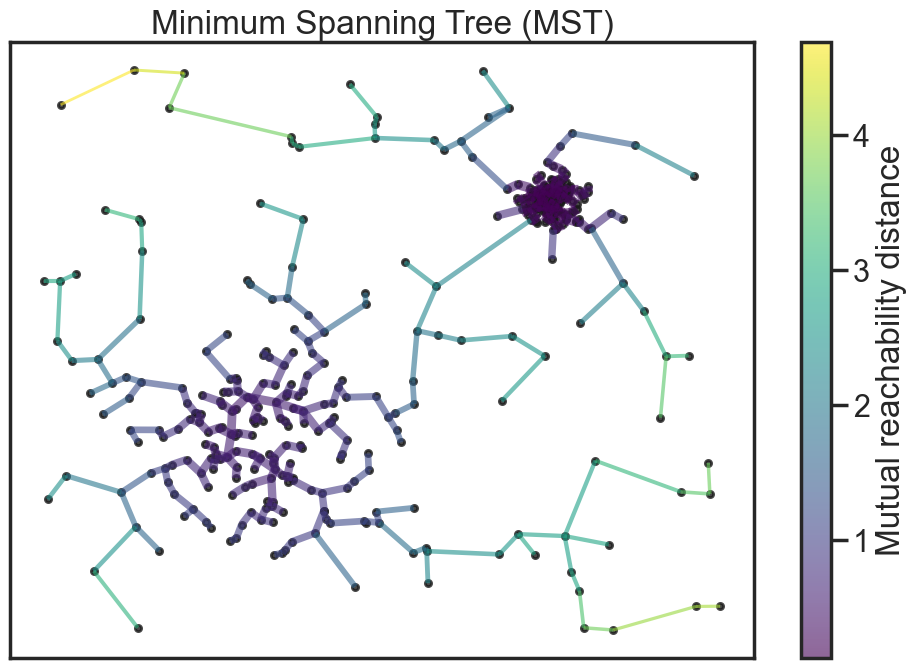

In [5]:
plt.figure(figsize=(12, 8))

# Plot the Minimum Spanning Tree
# Lines represent the "Mutual Reachability Distance" between points.
clusterer.minimum_spanning_tree_.plot(edge_cmap='viridis', 
                                      edge_alpha=0.6, 
                                      node_size=20, 
                                      edge_linewidth=2)
plt.title('Minimum Spanning Tree (MST)')
plt.show()

## Step 4: Build the Hierarchy (Dendrogram)
By sorting the edges of the MST from shortest to longest, HDBSCAN builds a hierarchical tree (a Dendrogram), just like standard Agglomerative Clustering. 
As the "distance" threshold increases, clusters merge together.

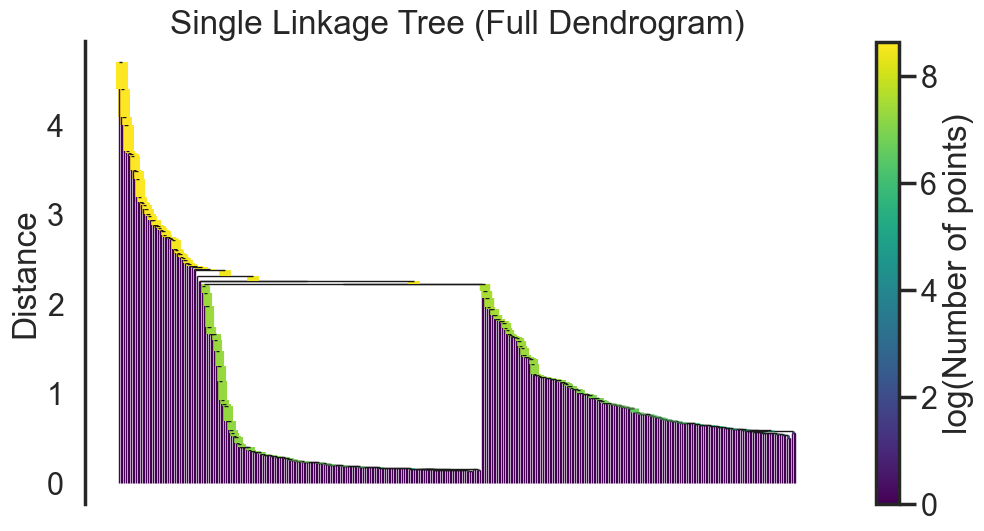

In [6]:
plt.figure(figsize=(12, 6))

# Plot the Single Linkage Tree
clusterer.single_linkage_tree_.plot(cmap='viridis', colorbar=True)
plt.title('Single Linkage Tree (Full Dendrogram)')
plt.ylabel('Distance')
plt.show()

## Step 5: Condense the Tree (The HDBSCAN Magic)
The tree above is incredibly messy. It contains every single point falling off the cluster one by one (which is mostly just noise).

HDBSCAN fixes this by **condensing** the tree. It looks at our `min_cluster_size = 15`. 
- If a split results in a group with fewer than 15 points, HDBSCAN says: *"That's not a new cluster, that's just a few noise points falling off."*
- If a split results in two groups that both have 15+ points, HDBSCAN says: *"This is a true cluster split!"*

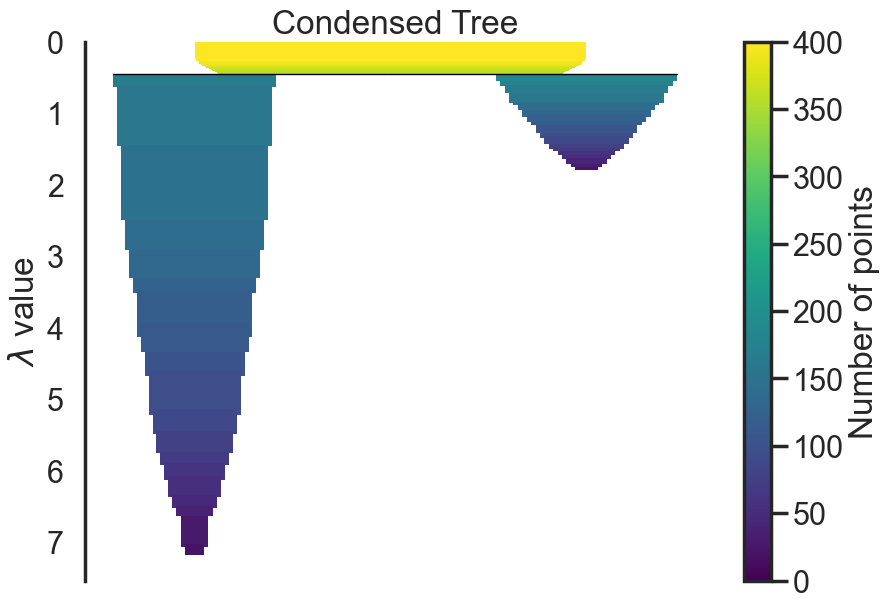

In [7]:
plt.figure(figsize=(10, 7))

# Plot the Condensed Tree
clusterer.condensed_tree_.plot()
plt.title('Condensed Tree')
plt.show()

### 🧠 How to read this plot:
The width of the lines represents the number of points in the cluster. 
As you move down (which is actually increasing density/decreasing distance), points "fall off" (represented by the lines getting thinner). 
The branches that survive and have a large area (stability) are our true clusters!

## Step 6: Extract the Clusters (Stability)
Instead of just drawing a straight horizontal line to cut the tree (like standard Hierarchical Clustering), HDBSCAN selects clusters based on **Stability** (the total area of the "ink" in the branch).

Let's ask the algorithm to circle the clusters it ultimately selected based on stability.

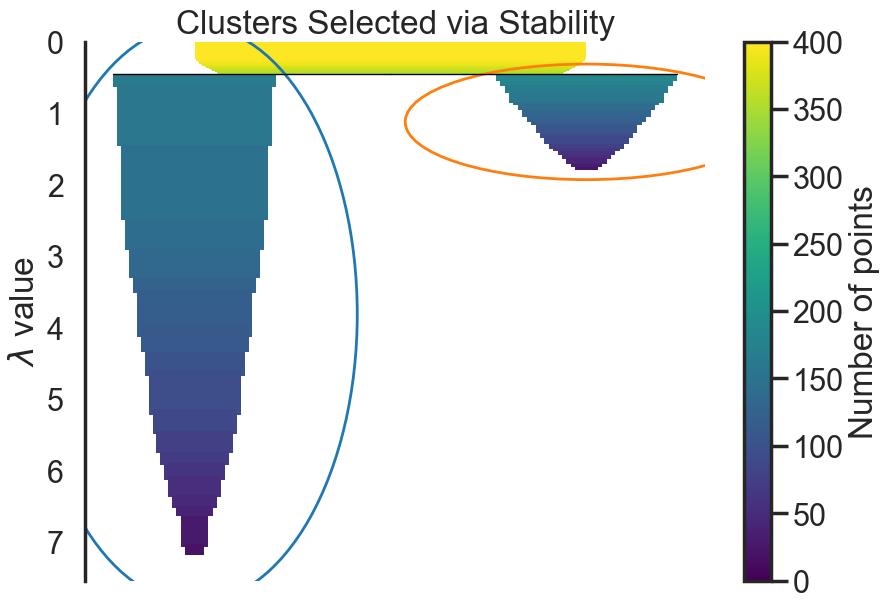

In [8]:
plt.figure(figsize=(10, 7))

# Highlight the selected clusters
clusterer.condensed_tree_.plot(select_clusters=True, selection_palette=sns.color_palette())
plt.title('Clusters Selected via Stability')
plt.show()

## Step 7: Final Visual Result
Now that the algorithm has run the math (MST -> Hierarchy -> Condensed Tree -> Stability Extraction), let's plot the raw data again, but color it by the final HDBSCAN labels.

*Crucial concept:* In HDBSCAN, a label of `-1` means the point was classified as **Noise**.

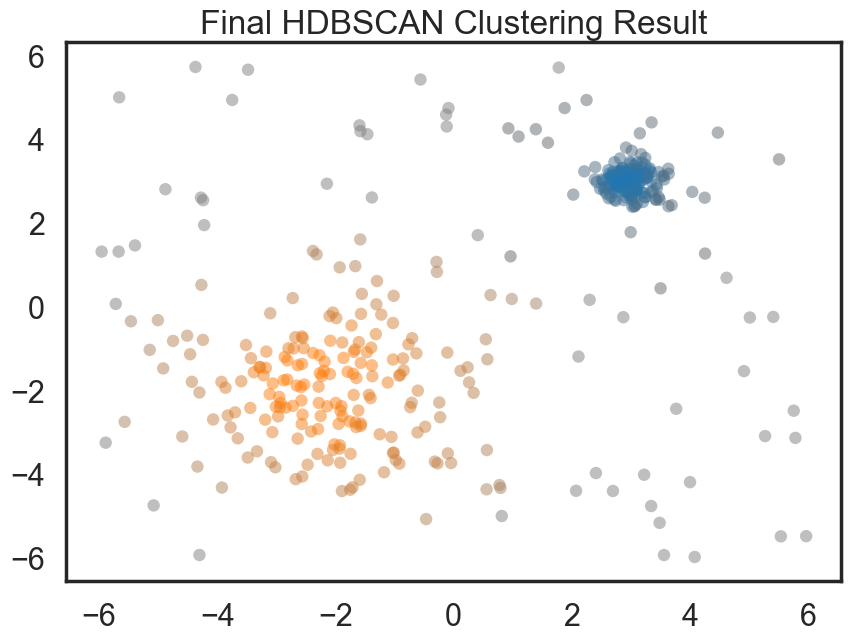

HDBSCAN found 2 clusters, and classified 49 points as noise.


In [9]:
# Get the labels (-1 means noise)
labels = clusterer.labels_

# Set up colors (Grey for noise, distinct colors for clusters)
palette = sns.color_palette()
cluster_colors = [sns.desaturate(palette[col], sat) 
                  if col >= 0 else (0.5, 0.5, 0.5) for col, sat in 
                  zip(clusterer.labels_, clusterer.probabilities_)]

plt.figure(figsize=(10, 7))
plt.scatter(data[:, 0], data[:, 1], c=cluster_colors, **plot_kwds)
plt.title('Final HDBSCAN Clustering Result')
plt.show()

print(f"HDBSCAN found {len(set(labels)) - 1} clusters, and classified {(labels == -1).sum()} points as noise.")

### 🎉 Conclusion
Notice the brilliance of HDBSCAN:
1. It successfully identified the tight cluster.
2. It successfully identified the sparse cluster (despite the density being totally different).
3. It correctly ignored the uniform background points, marking them as grey noise.

You now understand the pipeline: **Data -> Mutual Reachability Distance -> Minimum Spanning Tree -> Single Linkage -> Condensed Tree -> Stable Clusters**!